# SIREN 라벨 분석
dataset_index.csv 기반 표면처리 도메인 분석

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

# 한글 폰트 설정 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)

CSV_PATH = Path.home() / 'Desktop/Final_PJ/siren-api/vision/data/dataset_index.csv'
OUTPUT_DIR = Path.home() / 'Desktop/Final_PJ/siren-api/vision/data'

df = pd.read_csv(CSV_PATH)
print(f'총 row 수: {len(df):,}')
df.head()

총 row 수: 182,131


,file_name,split,domain,defect_name,part_name,category_id,label_type,width,height,date_captured,area,zip_source
0,2102_12_18abe76f-9272-4b9b-bb64-435c3d8337f0.JPG,TL,표면처리,균열,도장,2102,segmentation+bbox,3024,4032,2023-09-19 15:37:23,491417.3,TL_표면처리_균열_도장.zip
1,2102_12_0453f25b-076d-4c2d-8839-223ba37f6abf.JPG,TL,표면처리,균열,도장,2102,segmentation+bbox,3248,2432,2023-09-07 16:58:44,194051.5,TL_표면처리_균열_도장.zip
2,2102_12_0453f25b-076d-4c2d-8839-223ba37f6abf.JPG,TL,표면처리,균열,도장,2102,segmentation+bbox,3248,2432,2023-09-07 16:58:44,291465.5,TL_표면처리_균열_도장.zip
3,2102_12_0453f25b-076d-4c2d-8839-223ba37f6abf.JPG,TL,표면처리,균열,도장,2102,segmentation+bbox,3248,2432,2023-09-07 16:58:44,117738.4,TL_표면처리_균열_도장.zip
4,2102_12_a56ff778-8924-407c-8197-a41c633d3b1d.jpg,TL,표면처리,균열,도장,2102,segmentation+bbox,2992,2992,2023-09-19 10:06:04,413034.6,TL_표면처리_균열_도장.zip


## 1. 기본 현황

In [2]:
print('=== 컬럼 타입 ===')
print(df.dtypes)
print()
print('=== 결측치 ===')
print(df.isnull().sum())
print()
print('=== TL / VL 비율 ===')
print(df['split'].value_counts())
print()
print('=== 도메인 분포 ===')
print(df['domain'].value_counts())

=== 컬럼 타입 ===
file_name            str
split                str
domain               str
defect_name          str
part_name            str
category_id        int64
label_type           str
width              int64
height             int64
date_captured        str
area             float64
zip_source           str
dtype: object

=== 결측치 ===
file_name            0
split                0
domain               0
defect_name          0
part_name            0
category_id          0
label_type           0
width                0
height               0
date_captured        0
area             70807
zip_source           0
dtype: int64

=== TL / VL 비율 ===
split
TL    161952
VL     20179
Name: count, dtype: int64

=== 도메인 분포 ===
domain
표면처리    182128
용접           3
Name: count, dtype: int64


## 2. 클래스별 샘플 수

In [3]:
defect_counts = df.groupby(['defect_name', 'split']).size().unstack(fill_value=0)
print(defect_counts)
print()
print(f'총 클래스 수: {len(defect_counts)}')

split           TL    VL
defect_name             
균열           25184  3071
도막떨어짐        10669  1283
도막분리          9521  1200
도장흐름         10381  1272
보온재손상         9750  1232
스크래치         33504  4254
용접불량             1     0
용접양품             2     0
탱크클리닝불량      18443  2305
표면양품         44497  5562

총 클래스 수: 10


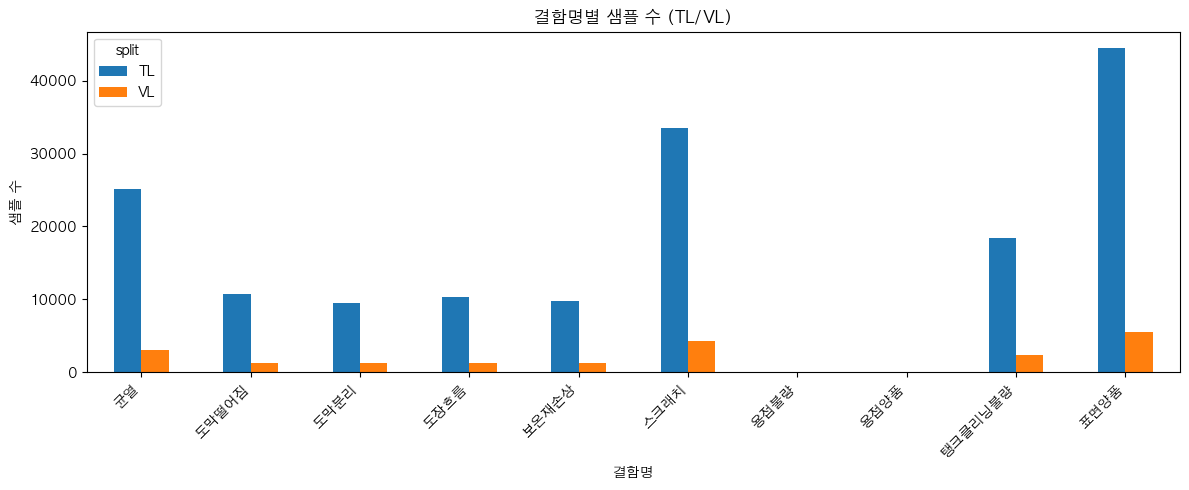

In [4]:
defect_counts.plot(kind='bar', figsize=(12, 5))
plt.title('결함명별 샘플 수 (TL/VL)')
plt.xlabel('결함명')
plt.ylabel('샘플 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'defect_counts.png', dpi=150)
plt.show()

## 3. 양품 vs 불량 비율

In [5]:
# category_id 끝자리 1=양품, 2=불량
df['is_defect'] = df['category_id'].apply(lambda x: x % 10 == 2)

ratio = df['is_defect'].value_counts()
ratio.index = ['불량', '양품']
print('=== 전체 기준 ===')
print(ratio)
print()

# TL / VL 각각
for split in ['TL', 'VL']:
    sub = df[df['split'] == split]['is_defect'].value_counts(normalize=True)
    print(f'=== {split} 기준 ===')
    print(f'  불량: {sub.get(True, 0)*100:.1f}%')
    print(f'  양품: {sub.get(False, 0)*100:.1f}%')

=== 전체 기준 ===
불량    132070
양품     50061
Name: count, dtype: int64

=== TL 기준 ===
  불량: 72.5%
  양품: 27.5%
=== VL 기준 ===
  불량: 72.4%
  양품: 27.6%


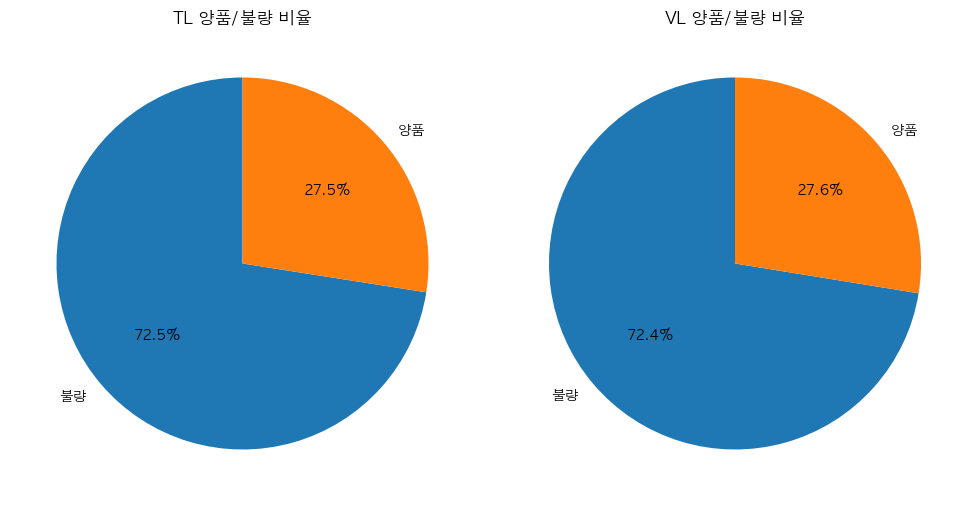

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, split in zip(axes, ['TL', 'VL']):
    sub = df[df['split'] == split]['is_defect'].value_counts()
    sub.index = ['불량', '양품']
    ax.pie(sub, labels=sub.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'{split} 양품/불량 비율')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'defect_ratio.png', dpi=150)
plt.show()

## 4. part_name × defect_name 조합 (RAG 매뉴얼 작성 범위)

In [7]:
combo = (
    df.groupby(['defect_name', 'part_name'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
print(f'총 조합 수: {len(combo)}개  ← 매뉴얼 작성 필요 문서 수')
print()
print(combo.to_string(index=False))
combo.to_csv(OUTPUT_DIR / 'combo_counts.csv', index=False)

총 조합 수: 16개  ← 매뉴얼 작성 필요 문서 수

defect_name part_name  count
    탱크클리닝불량        모재  20748
       표면양품        모재  20029
       표면양품       보온재  17121
         균열        도장  14859
       스크래치       보온재  13427
       스크래치        도장  13421
         균열       보온재  13396
       표면양품        도장  12909
      도막떨어짐        도장  11952
       도장흐름        도장  11653
      보온재손상       보온재  10982
       스크래치        모재  10910
       도막분리        도장  10721
       용접불량        도장      1
       용접양품        도장      1
       용접양품       보온재      1


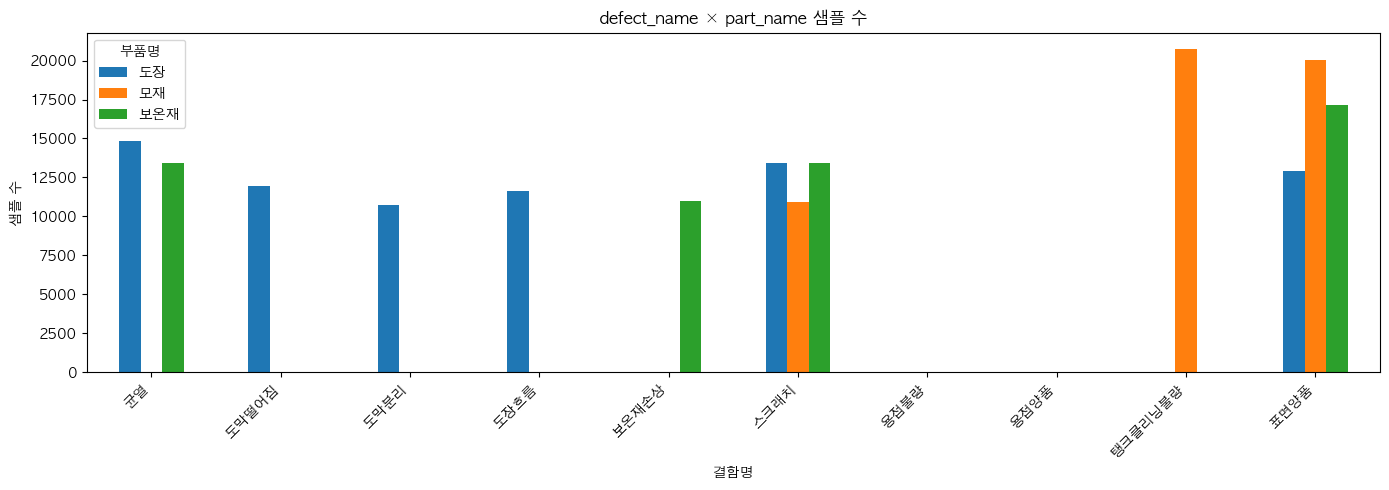

In [8]:
combo_pivot = combo.pivot(index='defect_name', columns='part_name', values='count').fillna(0)
combo_pivot.plot(kind='bar', figsize=(14, 5))
plt.title('defect_name × part_name 샘플 수')
plt.xlabel('결함명')
plt.ylabel('샘플 수')
plt.xticks(rotation=45, ha='right')
plt.legend(title='부품명')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'combo_counts.png', dpi=150)
plt.show()

## 5. 라벨 타입 분포 (시각화 전략 확정)

split                 TL     VL
label_type                     
classification     62940   7867
segmentation+bbox  99012  12312


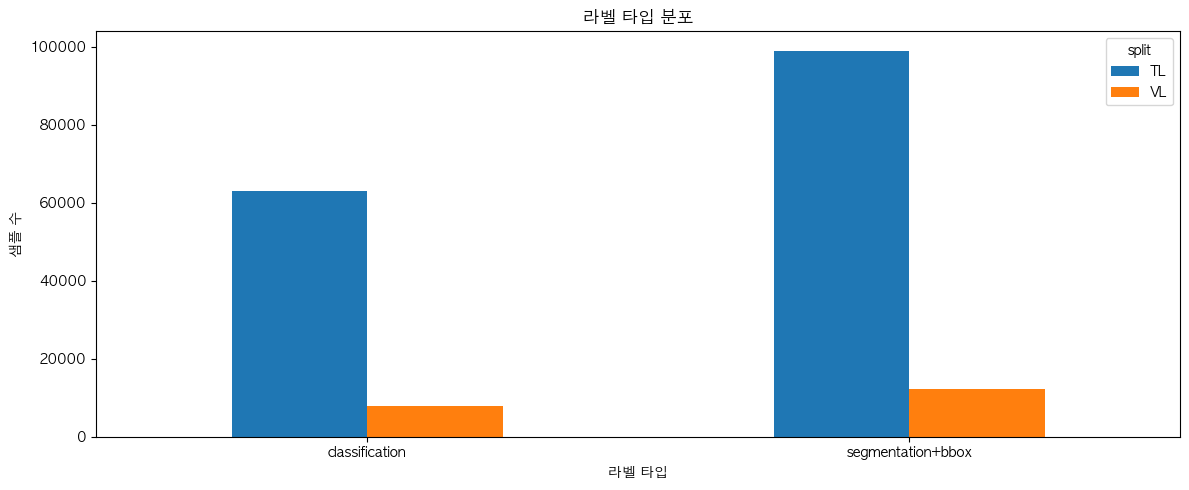

In [9]:
label_type = df.groupby(['label_type', 'split']).size().unstack(fill_value=0)
print(label_type)

label_type.plot(kind='bar')
plt.title('라벨 타입 분포')
plt.xlabel('라벨 타입')
plt.ylabel('샘플 수')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'label_type.png', dpi=150)
plt.show()

## 6. 해상도 확인 (YOLOv8 입력 사이즈)

In [10]:
resolutions = df.groupby(['width', 'height']).size().reset_index(name='count')
print('=== 해상도 분포 ===')
print(resolutions.sort_values('count', ascending=False))

=== 해상도 분포 ===
      width  height  count
1027   3024    4032  56272
681    3000    4000  34209
1170   3248    2432  24697
671    2992    2992  23390
1349   4000    3000  13385
...     ...     ...    ...
611    2928    4032      1
610    2927    4032      1
609    2927    4027      1
608    2925    3723      1
860    3024    3555      1

[1721 rows x 3 columns]


## 7. 데이터 품질 — 이상값 확인

In [11]:
# area 이상값
df['area'] = pd.to_numeric(df['area'], errors='coerce')
zero_area = df[df['area'] <= 0]
print(f'area=0 이하: {len(zero_area)}개')

# 유효하지 않은 category_id
VALID_IDS = {
    1101, 1102, 1202,
    2101, 2102, 2202, 2302, 2402, 2502, 2602, 2702,
    3101, 3102,
    4101, 4102, 4201, 4202, 4301, 4302,
    5101, 5102,
    6101, 6102,
}
invalid_ids = df[~df['category_id'].isin(VALID_IDS)]
print(f'유효하지 않은 category_id: {len(invalid_ids)}개')
if len(invalid_ids) > 0:
    print(invalid_ids['category_id'].value_counts())

print()
print('=== 품질 요약 ===')
print(f'전체 row:              {len(df):,}개')
print(f'area 이상값:           {len(zero_area)}개')
print(f'유효하지 않은 category: {len(invalid_ids)}개')

area=0 이하: 0개
유효하지 않은 category_id: 0개

=== 품질 요약 ===
전체 row:              182,131개
area 이상값:           0개
유효하지 않은 category: 0개


## 8. 촬영 기간 분포

=== 월별 촬영 분포 ===
year_month
2023-05       11
2023-07     3251
2023-08    84912
2023-09    47628
2023-10    46329
Freq: M, dtype: int64


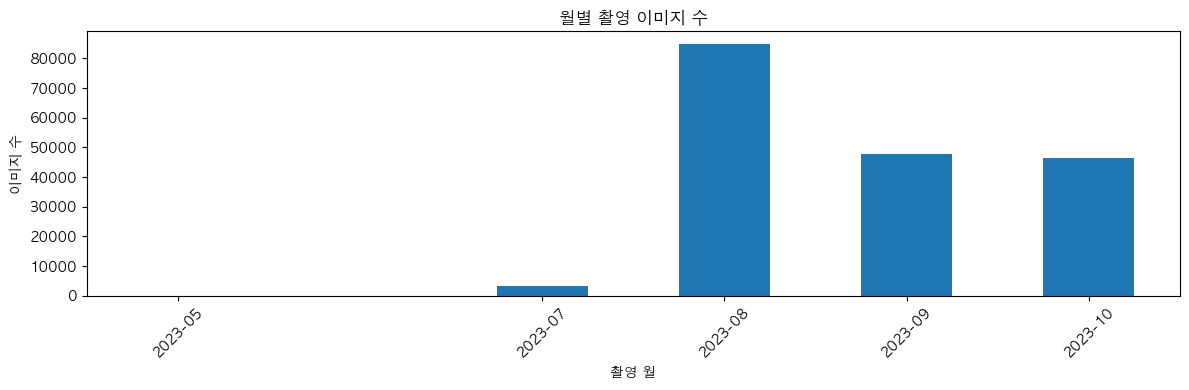

In [12]:
df['date_captured'] = pd.to_datetime(df['date_captured'], errors='coerce')
df['year_month'] = df['date_captured'].dt.to_period('M')

date_dist = df.groupby('year_month').size()
print('=== 월별 촬영 분포 ===')
print(date_dist)

date_dist.plot(kind='bar', figsize=(12, 4))
plt.title('월별 촬영 이미지 수')
plt.xlabel('촬영 월')
plt.ylabel('이미지 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'date_distribution.png', dpi=150)
plt.show()

## 9. 분석 요약

In [13]:
print('=' * 50)
print('SIREN 표면처리 라벨 분석 요약')
print('=' * 50)
print(f'총 이미지 수:      {len(df):,}개')
print(f'TL:                {len(df[df["split"]=="TL"]):,}개')
print(f'VL:                {len(df[df["split"]=="VL"]):,}개')
print(f'결함 클래스 수:    {df["defect_name"].nunique()}개')
print(f'부품 종류:         {df["part_name"].nunique()}개')
print(f'RAG 매뉴얼 범위:   {len(combo)}개 조합')
print(f'라벨 타입:         {df["label_type"].unique()}')
print(f'해상도:            {df[["width","height"]].drop_duplicates().values}')
print()
print('불량 클래스별 최소 샘플 수:')
defect_only = df[df['is_defect'] == True]
min_samples = defect_only.groupby('defect_name').size().sort_values()
print(min_samples)
print()
print(f'→ 샘플링 기준 추천: {min_samples.min()}장 이하 클래스 주의')

SIREN 표면처리 라벨 분석 요약
총 이미지 수:      182,131개
TL:                161,952개
VL:                20,179개
결함 클래스 수:    10개
부품 종류:         3개
RAG 매뉴얼 범위:   16개 조합
라벨 타입:         <ArrowStringArray>
['segmentation+bbox', 'classification']
Length: 2, dtype: str
해상도:            [[3024 4032]
 [3248 2432]
 [2992 2992]
 ...
 [2585 4024]
 [2329 4032]
 [3015 3885]]

불량 클래스별 최소 샘플 수:
defect_name
용접불량           1
도막분리       10721
보온재손상      10982
도장흐름       11653
도막떨어짐      11952
탱크클리닝불량    20748
균열         28255
스크래치       37758
dtype: int64

→ 샘플링 기준 추천: 1장 이하 클래스 주의


In [15]:
# 1. 용접불량 1개 어디서 왔는지
df[df['defect_name'] == '용접불량'][['file_name', 'zip_source']]


,file_name,zip_source
2146,2102_12_24a0047d-4aba-488a-b173-cece8745f8c6.jpg,TL_표면처리_균열_도장.zip


In [16]:

# 2. classification 타입 몇 개인지
df[df['label_type'] == 'classification'].shape


(70807, 14)

In [17]:
# 3. 해상도 분포 상세
df.groupby(['width', 'height']).size().sort_values(ascending=False).head(10)

width  height
3024   4032      56272
3000   4000      34209
3248   2432      24697
2992   2992      23390
4000   3000      13385
2432   3248      13340
4032   3024      11202
3024   3024       2339
3072   4096        694
4096   3072        335
dtype: int64

In [18]:
# 노트북에서 확인
df.groupby(['defect_name', 'label_type']).size().unstack(fill_value=0)

label_type,classification,segmentation+bbox
defect_name,,
균열,0,28255
도막떨어짐,0,11952
도막분리,0,10721
도장흐름,0,11653
보온재손상,0,10982
스크래치,0,37758
용접불량,0,1
용접양품,0,2
탱크클리닝불량,20748,0


=== 클래스별 샘플 수 (TL) ===
defect_name
용접불량           1
용접양품           2
도막분리        9521
보온재손상       9750
도장흐름       10381
도막떨어짐      10669
탱크클리닝불량    18443
균열         25184
스크래치       33504
표면양품       44497
dtype: int64

=== 500장 미만 클래스 ===
defect_name
용접불량    1
용접양품    2
dtype: int64


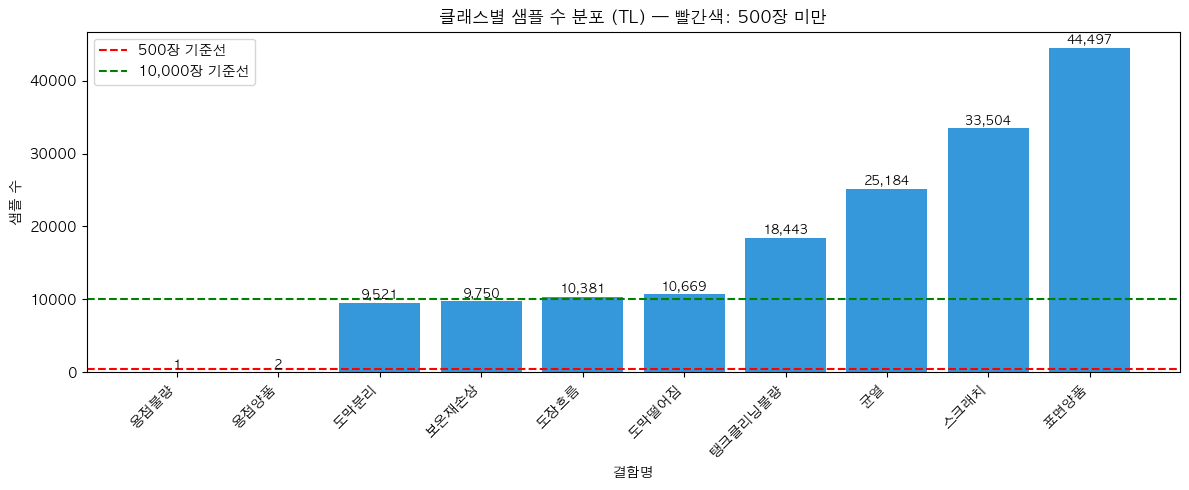


=== 샘플링 전략 ===
⚠️  500장 미만 클래스 존재
→ Stratified Sampling 적용
→ 500장 미만 클래스: 전체 사용
→ 500장 이상 클래스: 500장 랜덤 샘플링

확정 전략: stratified


In [19]:
# ── 투두리스트 실행 ────────────────────────────────────────
# 1. 전체 클래스별 파일 수 카운트
# 2. 500장 미만 클래스 식별
# 3. 불균형 시각화
# 4. 샘플링 전략 결정

# 1. 클래스별 파일 수 (TL 기준)
tl = df[df['split'] == 'TL']
class_counts = tl.groupby('defect_name').size().sort_values()
print('=== 클래스별 샘플 수 (TL) ===')
print(class_counts)

# 2. 500장 미만 클래스 식별
under_500 = class_counts[class_counts < 500]
print(f'\n=== 500장 미만 클래스 ===')
if len(under_500) == 0:
    print('없음 ✅')
else:
    print(under_500)

# 3. 시각화
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if v < 500 else '#3498db' for v in class_counts.values]
bars = ax.bar(class_counts.index, class_counts.values, color=colors)

ax.axhline(y=500, color='red', linestyle='--', linewidth=1.5, label='500장 기준선')
ax.axhline(y=10000, color='green', linestyle='--', linewidth=1.5, label='10,000장 기준선')

for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

ax.set_title('클래스별 샘플 수 분포 (TL) — 빨간색: 500장 미만')
ax.set_xlabel('결함명')
ax.set_ylabel('샘플 수')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150)
plt.show()

# 4. 샘플링 전략 결정
print('\n=== 샘플링 전략 ===')
if len(under_500) > 0:
    print('⚠️  500장 미만 클래스 존재')
    print('→ Stratified Sampling 적용')
    print('→ 500장 미만 클래스: 전체 사용')
    print('→ 500장 이상 클래스: 500장 랜덤 샘플링')
    SAMPLING_STRATEGY = 'stratified'
else:
    min_count = class_counts.min()
    print(f'✅ 모든 클래스 500장 이상')
    print(f'→ 최소 샘플 수: {min_count:,}장')
    print(f'→ 균등 샘플링: 클래스당 500장')
    SAMPLING_STRATEGY = 'uniform'

print(f'\n확정 전략: {SAMPLING_STRATEGY}')